In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from skimage.feature import local_binary_pattern

In [11]:
image = cv2.imread('/content/drive/MyDrive/Colab Notebooks/datasets/ashfaq.jpg')
image_path = '/content/drive/MyDrive/Colab Notebooks/datasets/ashfaq.jpg'

RGB Histogram Features: [0.31995383 0.27537677 0.10153909 0.09587476 0.07308021 0.06152887
 0.04131925 0.03132725 0.316485   0.35858536 0.13629846 0.05796928
 0.0653947  0.03163898 0.01558668 0.01804157 0.43032908 0.3840906
 0.10743126 0.05025134 0.0111751  0.00695277 0.00403328 0.00573655]


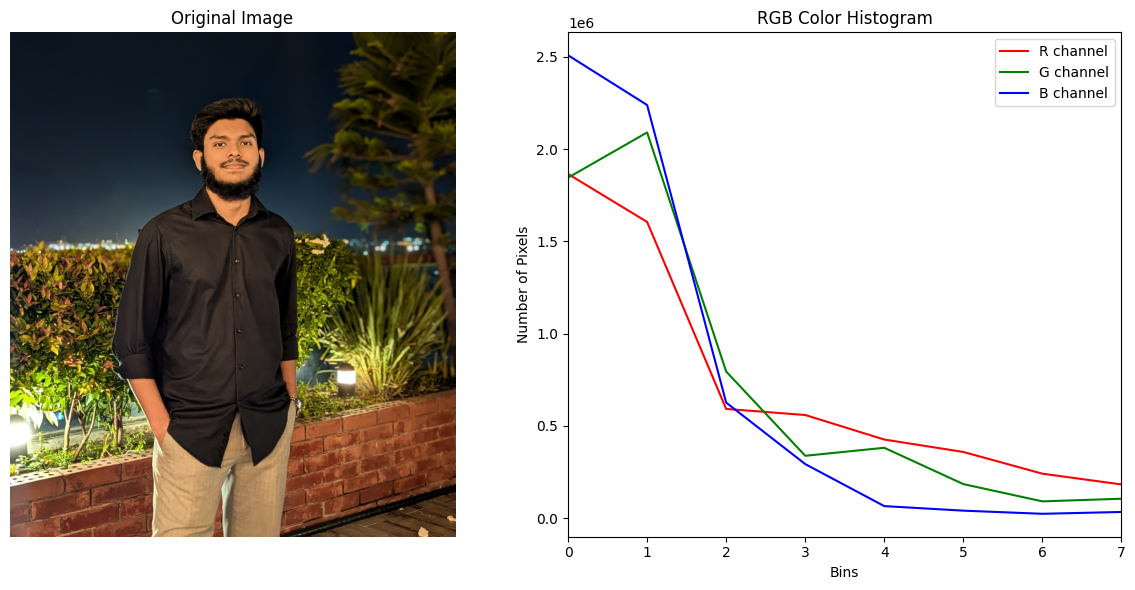

In [12]:
def rgb_color_histogram(image_path, bins=8):
    # Load the image
    image = cv2.imread(image_path)
    # Convert from BGR (OpenCV default) to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Split into RGB channels
    r, g, b = cv2.split(image)

    # Calculate histograms for each channel
    hist_r = cv2.calcHist([r], [0], None, [bins], [0, 256])
    hist_g = cv2.calcHist([g], [0], None, [bins], [0, 256])
    hist_b = cv2.calcHist([b], [0], None, [bins], [0, 256])

    # Normalize the histograms
    hist_r = hist_r / hist_r.sum()
    hist_g = hist_g / hist_g.sum()
    hist_b = hist_b / hist_b.sum()

    # Combine the histograms
    rgb_hist = np.concatenate([hist_r, hist_g, hist_b]).flatten()

    return rgb_hist

def plot_rgb_histogram(image_path, bins=8):
    # Load the image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Create figure
    plt.figure(figsize=(12, 6))

    # Display the image
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title('Original Image')
    plt.axis('off')

    # Calculate and plot histogram
    plt.subplot(1, 2, 2)
    colors = ('r', 'g', 'b')
    for i, color in enumerate(colors):
        hist = cv2.calcHist([image], [i], None, [bins], [0, 256])
        plt.plot(hist, color=color, label=f'{color.upper()} channel')

    plt.title('RGB Color Histogram')
    plt.xlabel('Bins')
    plt.ylabel('Number of Pixels')
    plt.legend()
    plt.xlim([0, bins-1])

    plt.tight_layout()
    plt.show()

histogram_features = rgb_color_histogram(image_path)
print("RGB Histogram Features:", histogram_features)

# Visualize the histogram
plot_rgb_histogram(image_path)

LBP Feature Vector: [0.00747089 0.03089902 0.01368267 0.11753958 0.19840601 0.23270387
 0.05920796 0.06084913 0.22876186 0.050479  ]
Feature Vector Length: 10


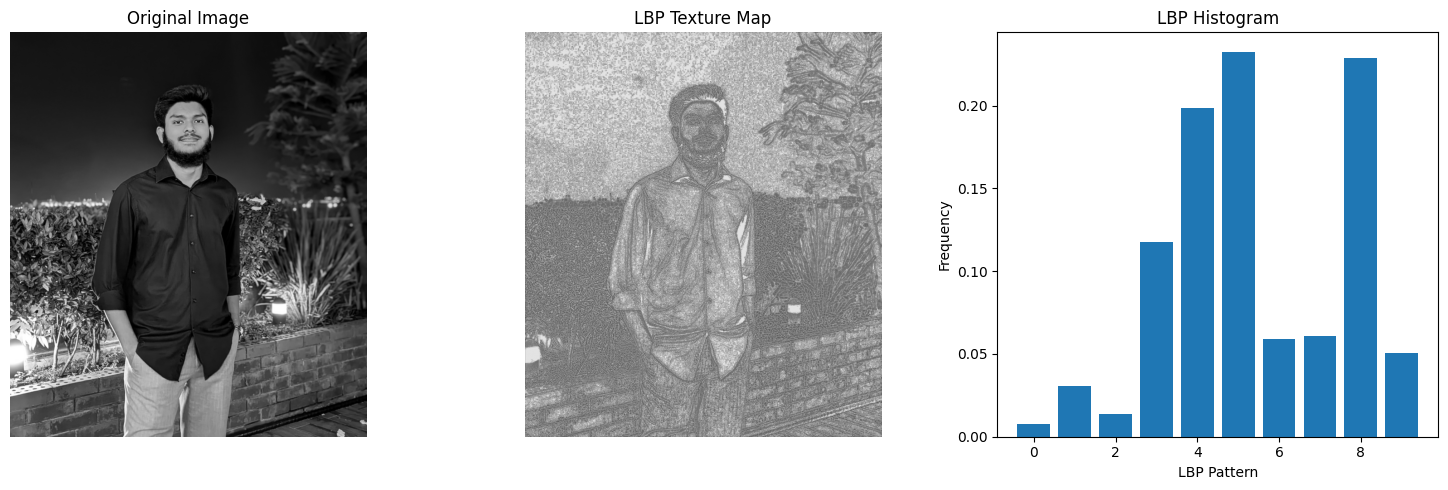

In [13]:
def extract_lbp_features(image_path, radius=1, n_points=8, method='uniform'):
    # Load the image in grayscale
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Compute LBP
    lbp = local_binary_pattern(image, n_points, radius, method)

    # Calculate histogram
    n_bins = int(lbp.max() + 1)
    hist, _ = np.histogram(lbp, density=True, bins=n_bins, range=(0, n_bins))

    return hist, lbp
def plot_lbp_results(original, lbp, hist):
    plt.figure(figsize=(15, 5))

    # Original image
    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    # LBP image
    plt.subplot(1, 3, 2)
    plt.imshow(lbp, cmap='gray')
    plt.title('LBP Texture Map')
    plt.axis('off')

    # LBP histogram
    plt.subplot(1, 3, 3)
    plt.bar(range(len(hist)), hist)
    plt.title('LBP Histogram')
    plt.xlabel('LBP Pattern')
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()
original_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
lbp_hist, lbp_image = extract_lbp_features(image_path)
print("LBP Feature Vector:", lbp_hist)
print("Feature Vector Length:", len(lbp_hist))
plot_lbp_results(original_img, lbp_image, lbp_hist)

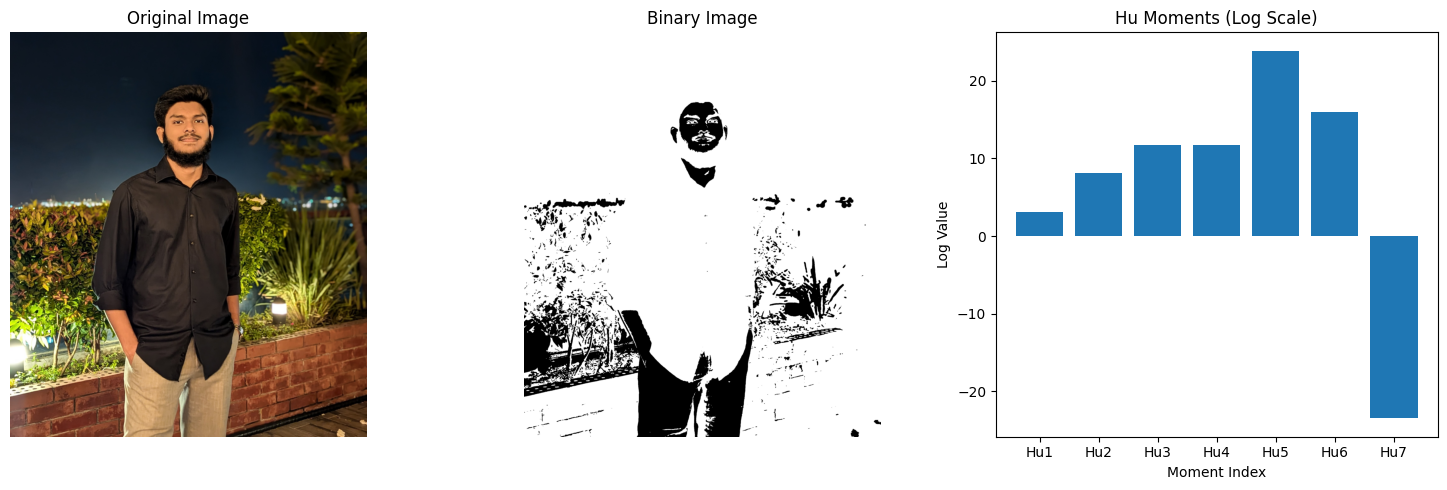

Spatial Moments:
M00 (Area): 1290984675.0
M10, M01: 1509659978550.0, 1542594818730.0
μ20, μ11, μ02 (Central Moments): 567157256563930.2, 38010413929276.5, 682098523399151.8

Hu Moments (Original Scale):
Hu1: 0.000750
Hu2: 0.000000
Hu3: 0.000000
Hu4: 0.000000
Hu5: 0.000000
Hu6: 0.000000
Hu7: -0.000000

Hu Moments (Log Scale):
Hu1: 3.125191
Hu2: 8.165144
Hu3: 11.779539
Hu4: 11.692776
Hu5: 23.849862
Hu6: 15.943838
Hu7: -23.462679


In [14]:
def preprocess_image(image_path):
    # Read image and convert to grayscale
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Threshold to create binary image
    _, binary = cv2.threshold(gray, 128, 255, cv2.THRESH_BINARY_INV)

    return image, binary

def calculate_moments(binary_image):
    # Calculate moments
    moments = cv2.moments(binary_image)

    # Calculate Hu moments
    hu_moments = cv2.HuMoments(moments)

    # Log scale Hu moments for better numerical behavior
    hu_moments_log = -np.sign(hu_moments) * np.log10(np.abs(hu_moments))

    return moments, hu_moments.flatten(), hu_moments_log.flatten()

def visualize_shape_features(image_path):
    # Preprocess image
    original, binary = preprocess_image(image_path)

    # Calculate moments
    moments, hu_moments, hu_log = calculate_moments(binary)

    # Visualization
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(binary, cmap='gray')
    plt.title('Binary Image')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.bar(range(7), hu_log)
    plt.title('Hu Moments (Log Scale)')
    plt.xlabel('Moment Index')
    plt.ylabel('Log Value')
    plt.xticks(range(7), [f'Hu{i+1}' for i in range(7)])

    plt.tight_layout()
    plt.show()

    return moments, hu_moments, hu_log

spatial_moments, hu_moments, hu_log = visualize_shape_features(image_path)

print("Spatial Moments:")
print(f"M00 (Area): {spatial_moments['m00']}")
print(f"M10, M01: {spatial_moments['m10']}, {spatial_moments['m01']}")
print(f"μ20, μ11, μ02 (Central Moments): {spatial_moments['mu20']}, {spatial_moments['mu11']}, {spatial_moments['mu02']}")

print("\nHu Moments (Original Scale):")
for i, val in enumerate(hu_moments):
    print(f"Hu{i+1}: {val:.6f}")

print("\nHu Moments (Log Scale):")
for i, val in enumerate(hu_log):
    print(f"Hu{i+1}: {val:.6f}")

In [15]:

gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Detect SIFT features
print("Keypoint Detection (SIFT)")
sift = cv2.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(gray_image, None)

# Draw keypoints
image_with_keypoints = cv2.drawKeypoints(
    image,
    keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

# Resize the output for smaller display
display_height = 1000
aspect_ratio = image.shape[1]/image.shape[0]
resized_display = cv2.resize(image_with_keypoints,
                           (int(display_height*aspect_ratio), display_height))

# Display results
cv2_imshow(resized_display)  # For Colab
# cv2.imshow('SIFT Keypoints', resized_display)  # For local Python
# cv2.waitKey(0)  # For local Python

print(f"Number of Keypoints Detected: {len(keypoints)}")
print(f"Descriptor Shape: {descriptors.shape}")  # (n_keypoints, 128)

Output hidden; open in https://colab.research.google.com to view.